# Project Overview: Fertilizer Recommendation & Type Prediction
**Objective:** Predict the optimal fertilizer type using soil NPK levels, moisture, temperature, and specific crop requirements.

## 1. Libraries & Workspace Setup

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e6')

print("Path to competition files:", path)

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e6/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e6/test.csv')

In [4]:
train_df.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [5]:
test_df.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous
0,750000,31,70,52,Sandy,Wheat,34,11,24
1,750001,27,62,45,Red,Sugarcane,30,14,15
2,750002,28,72,28,Clayey,Ground Nuts,14,15,4
3,750003,37,53,57,Black,Ground Nuts,18,17,36
4,750004,31,55,32,Red,Pulses,13,19,14


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               750000 non-null  int64 
 1   Temparature      750000 non-null  int64 
 2   Humidity         750000 non-null  int64 
 3   Moisture         750000 non-null  int64 
 4   Soil Type        750000 non-null  object
 5   Crop Type        750000 non-null  object
 6   Nitrogen         750000 non-null  int64 
 7   Potassium        750000 non-null  int64 
 8   Phosphorous      750000 non-null  int64 
 9   Fertilizer Name  750000 non-null  object
dtypes: int64(7), object(3)
memory usage: 57.2+ MB


In [7]:
train_df.shape

(750000, 10)

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           250000 non-null  int64 
 1   Temparature  250000 non-null  int64 
 2   Humidity     250000 non-null  int64 
 3   Moisture     250000 non-null  int64 
 4   Soil Type    250000 non-null  object
 5   Crop Type    250000 non-null  object
 6   Nitrogen     250000 non-null  int64 
 7   Potassium    250000 non-null  int64 
 8   Phosphorous  250000 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 17.2+ MB


In [9]:
test_df.shape

(250000, 9)

In [10]:
train_df.isnull().sum()

id                 0
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [11]:
test_df.isnull().sum()

id             0
Temparature    0
Humidity       0
Moisture       0
Soil Type      0
Crop Type      0
Nitrogen       0
Potassium      0
Phosphorous    0
dtype: int64

## 3. Exploratory Data Analysis

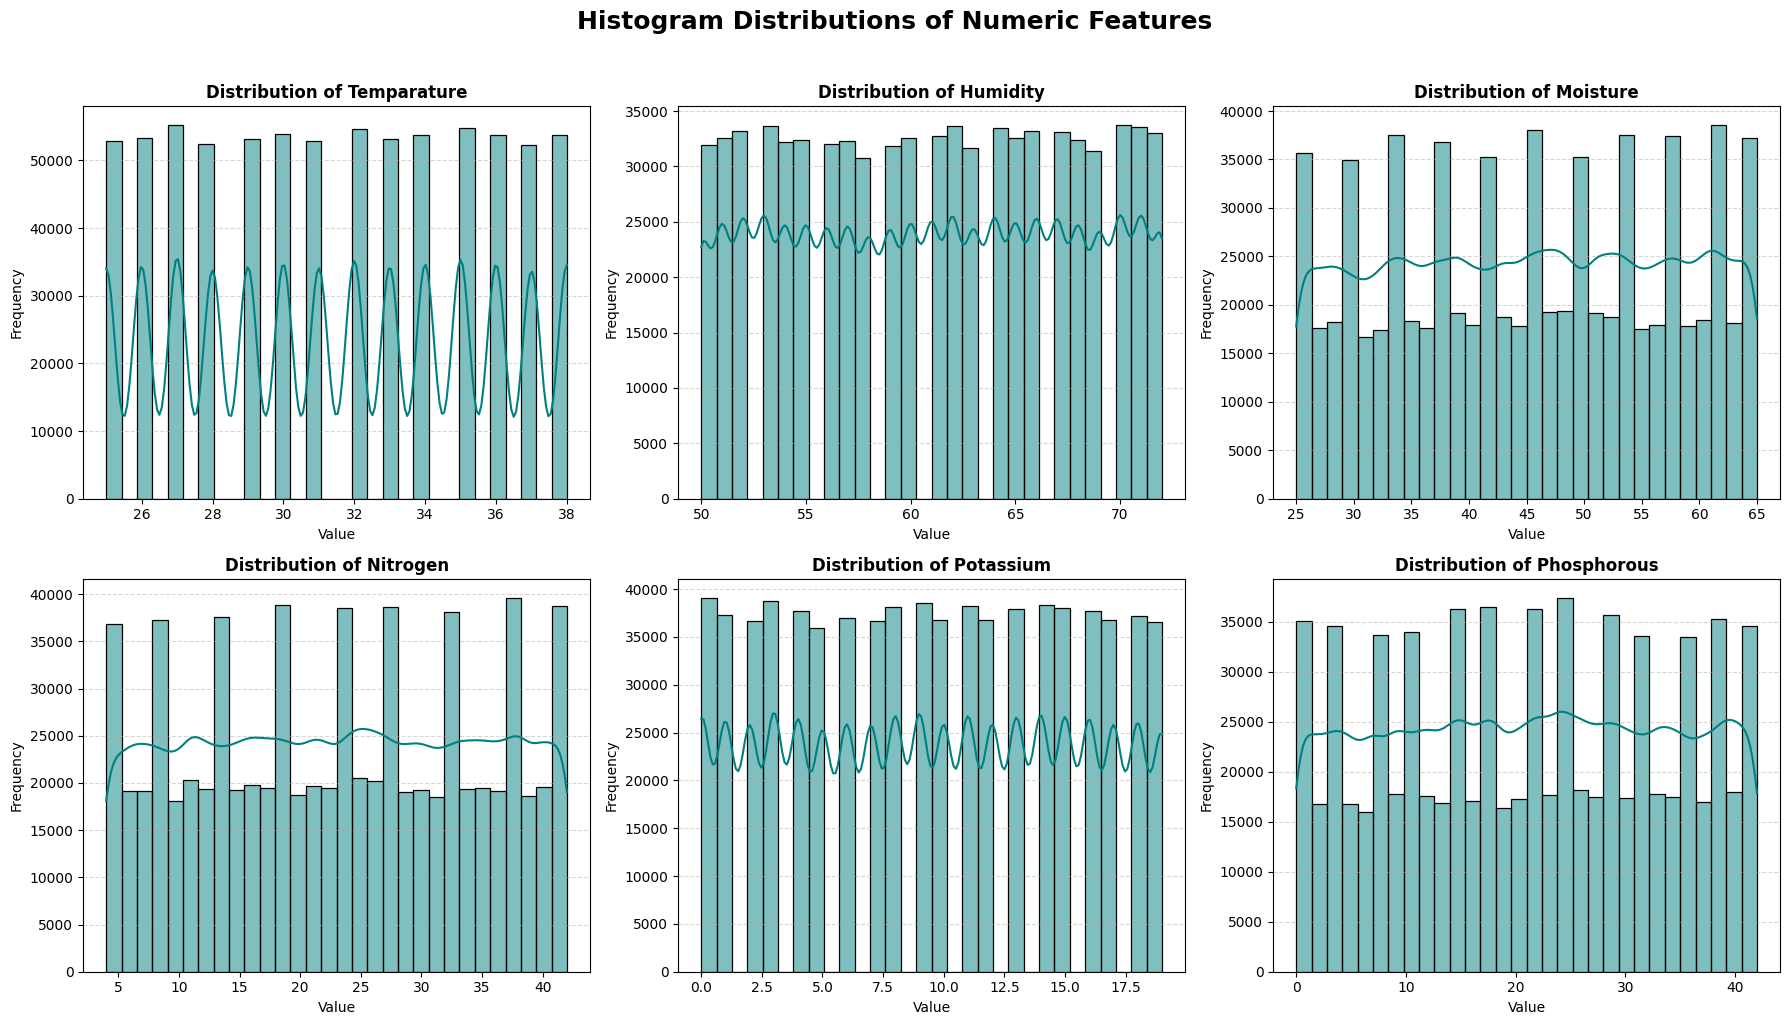

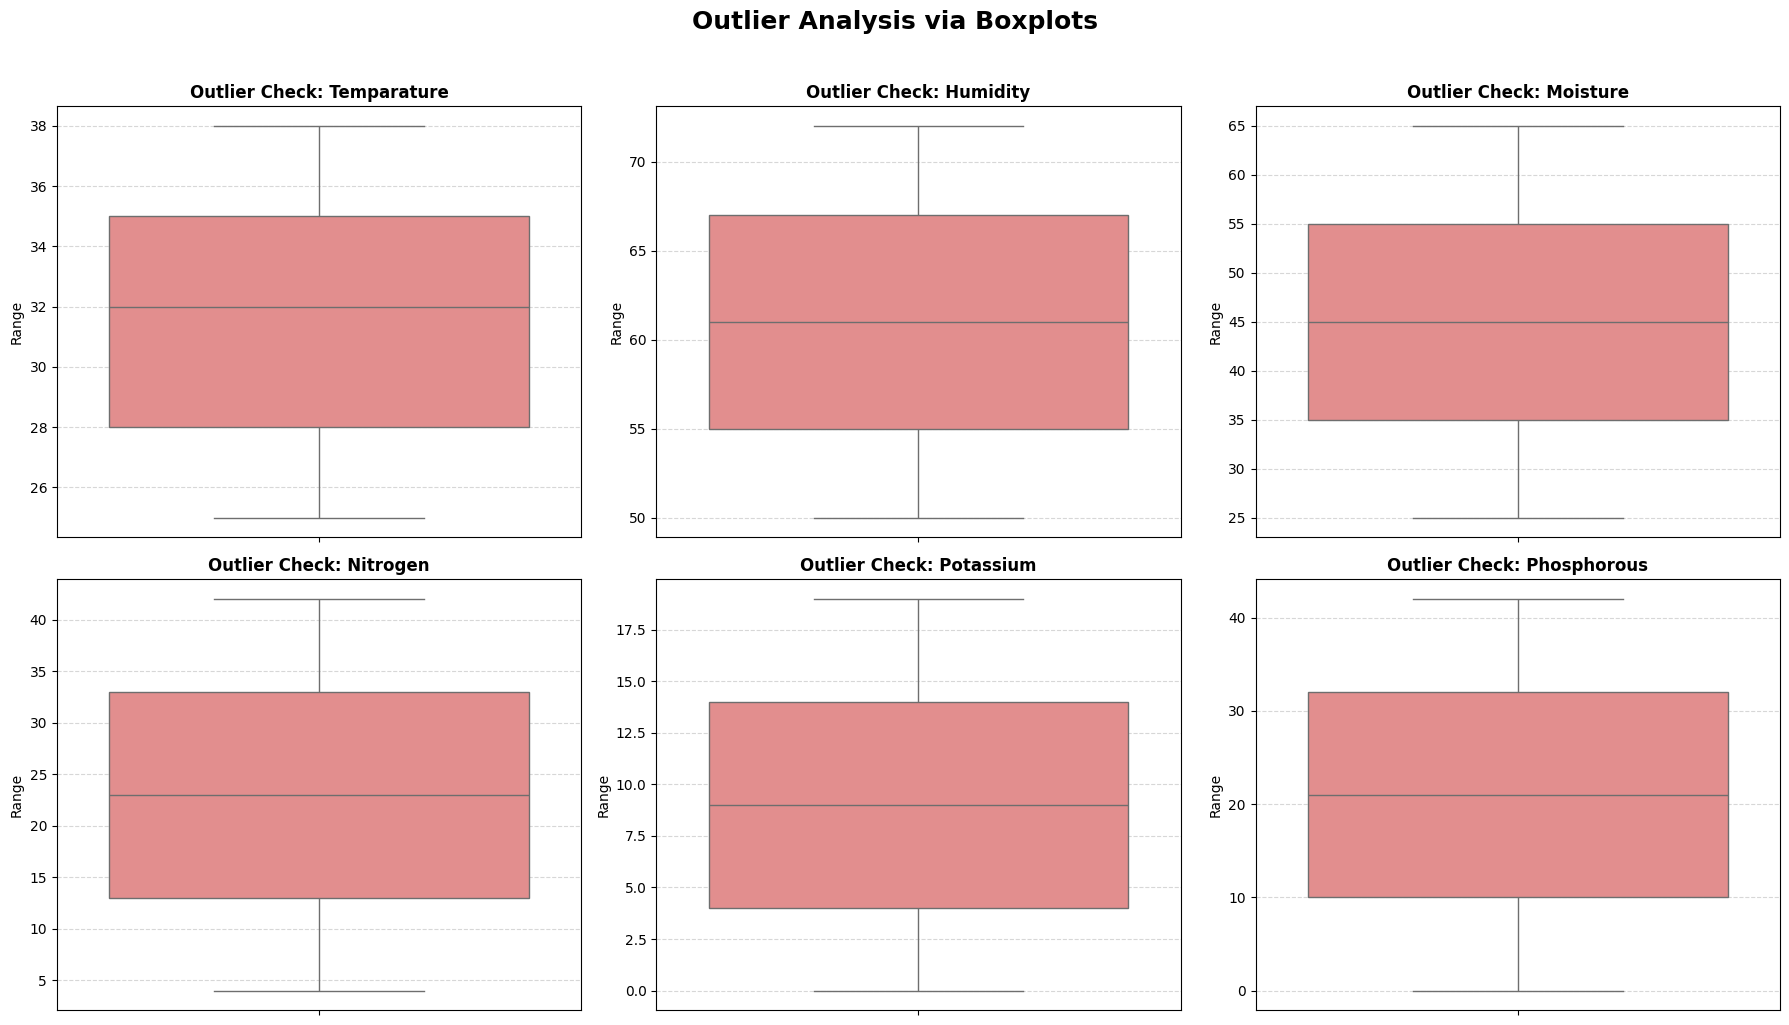

In [12]:
num_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

# Histogram
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
display(train_df[num_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temparature,750000.0,31.503565,4.025574,25.0,28.0,32.0,35.0,38.0
Humidity,750000.0,61.038912,6.647695,50.0,55.0,61.0,67.0,72.0
Moisture,750000.0,45.184147,11.794594,25.0,35.0,45.0,55.0,65.0
Nitrogen,750000.0,23.093808,11.216125,4.0,13.0,23.0,33.0,42.0
Potassium,750000.0,9.478296,5.765622,0.0,4.0,9.0,14.0,19.0
Phosphorous,750000.0,21.073227,12.346831,0.0,10.0,21.0,32.0,42.0


## 4. Feature Engineering (FE) & Data Preprocessing

In [14]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [15]:
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [16]:
combined_df

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,is_train
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,1
1,1,27,69,65,Sandy,Millets,30,6,18,28-28,1
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17,1
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26,1
4,4,35,58,43,Red,Paddy,37,2,16,DAP,1
...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,26,66,30,Red,Sugarcane,14,7,18,NaN,0
999996,999996,33,62,55,Red,Pulses,28,14,7,NaN,0
999997,999997,36,53,64,Black,Paddy,28,11,27,NaN,0
999998,999998,36,67,26,Clayey,Paddy,33,0,10,NaN,0


### 4.1. Agricultural Feature Engeneering

In [17]:
df_fe = combined_df.copy()

# Total NPK Load: Absolute sum of primary macronutrients available in the soil matrix
df_fe['Total_NPK'] = df_fe['Nitrogen'] + df_fe['Potassium'] + df_fe['Phosphorous']

In [18]:
# Nutrient Interaction Ratios: Core indicators for vegetative vs. structural development
df_fe['NP_Ratio'] = np.where(df_fe['Phosphorous'] == 0, 0, df_fe['Nitrogen'] / df_fe['Phosphorous'])
df_fe['NK_Ratio'] = np.where(df_fe['Potassium'] == 0, 0, df_fe['Nitrogen'] / df_fe['Potassium'])
df_fe['PK_Ratio'] = np.where(df_fe['Potassium'] == 0, 0, df_fe['Phosphorous'] / df_fe['Potassium'])

In [19]:
# Micro-climate & Atmospheric Indices: Evaluates ambient conditions affecting fertilizer solubility
df_fe['Temp_Humidity_Index'] = df_fe['Temparature'] * df_fe['Humidity']
df_fe['Moisture_Humidity_Ratio'] = np.where(df_fe['Humidity'] == 0, 0, df_fe['Moisture'] / df_fe['Humidity'])

# Calculate total nutrient load as a baseline reference for percentages
total_elements = df_fe['Nitrogen'] + df_fe['Phosphorous'] + df_fe['Potassium']

In [20]:
# Calculate the proportional percentage of each macronutrient within the total NPK pool
df_fe['N_Percentage'] = np.where(total_elements == 0, 0, df_fe['Nitrogen'] / total_elements)
df_fe['P_Percentage'] = np.where(total_elements == 0, 0, df_fe['Phosphorous'] / total_elements)
df_fe['K_Percentage'] = np.where(total_elements == 0, 0, df_fe['Potassium'] / total_elements)

In [21]:
# Capturing specific chemical signatures (Presence/Absence matrix)
# If Potassium (K) is zero, the formulation closely maps to DAP or NP-type compound fertilizers
df_fe['is_K_zero'] = (df_fe['Potassium'] == 0).astype(int)

In [22]:
# If both Phosphorous and Potassium are zero, it explicitly captures the Urea signature
df_fe['is_pure_N'] = ((df_fe['Phosphorous'] == 0) & (df_fe['Potassium'] == 0)).astype(int)

In [23]:
# Nitrogen and Phosphorous balance tracking
# A low absolute difference indicates a balanced/composite fertilizer structure
df_fe['NP_Equality'] = np.abs(df_fe['N_Percentage'] - df_fe['P_Percentage'])

In [24]:
df_fe

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,...,NK_Ratio,PK_Ratio,Temp_Humidity_Index,Moisture_Humidity_Ratio,N_Percentage,P_Percentage,K_Percentage,is_K_zero,is_pure_N,NP_Equality
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,...,9.000000,1.250000,2590,0.514286,0.800000,0.111111,0.088889,0,0,0.688889
1,1,27,69,65,Sandy,Millets,30,6,18,28-28,...,5.000000,3.000000,1863,0.942029,0.555556,0.333333,0.111111,0,0,0.222222
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17,...,2.000000,1.333333,1827,0.507937,0.461538,0.307692,0.230769,0,0,0.153846
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26,...,3.250000,0.333333,2170,0.870968,0.709091,0.072727,0.218182,0,0,0.636364
4,4,35,58,43,Red,Paddy,37,2,16,DAP,...,18.500000,8.000000,2030,0.741379,0.672727,0.290909,0.036364,0,0,0.381818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,26,66,30,Red,Sugarcane,14,7,18,NaN,...,2.000000,2.571429,1716,0.454545,0.358974,0.461538,0.179487,0,0,0.102564
999996,999996,33,62,55,Red,Pulses,28,14,7,NaN,...,2.000000,0.500000,2046,0.887097,0.571429,0.142857,0.285714,0,0,0.428571
999997,999997,36,53,64,Black,Paddy,28,11,27,NaN,...,2.545455,2.454545,1908,1.207547,0.424242,0.409091,0.166667,0,0,0.015152
999998,999998,36,67,26,Clayey,Paddy,33,0,10,NaN,...,0.000000,0.000000,2412,0.388060,0.767442,0.232558,0.000000,1,0,0.534884


### 4.2. Categorical Encoding

In [25]:
nominal_features = ['Soil Type', 'Crop Type']

df_encoded = pd.get_dummies(df_fe, columns=nominal_features, drop_first=True, dtype=int)

In [26]:
df_encoded

,id,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name,is_train,Total_NPK,...,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,0,37,70,36,36,4,5,28-28,1,45,...,0,0,0,0,0,0,0,1,0,0
1,1,27,69,65,30,6,18,28-28,1,54,...,0,0,0,1,0,0,0,0,0,0
2,2,29,63,32,24,12,16,17-17-17,1,52,...,0,0,0,1,0,0,0,0,0,0
3,3,35,62,54,39,12,4,10-26-26,1,55,...,0,0,0,0,0,0,0,0,0,0
4,4,35,58,43,37,2,16,DAP,1,55,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,26,66,30,14,7,18,NaN,0,39,...,0,0,0,0,0,0,0,1,0,0
999996,999996,33,62,55,28,14,7,NaN,0,49,...,0,0,0,0,0,0,1,0,0,0
999997,999997,36,53,64,28,11,27,NaN,0,66,...,0,0,0,0,0,1,0,0,0,0
999998,999998,36,67,26,33,0,10,NaN,0,43,...,0,0,0,0,0,1,0,0,0,0


### 4.3. Feature Alignment and Train-Test Split Verification

In [27]:
x_train = df_encoded[df_encoded['is_train'] == 1].copy()
x_test = df_encoded[df_encoded['is_train'] == 0].copy()
y_train = x_train['Fertilizer Name']

columns_to_drop = ['id', 'is_train', 'Fertilizer Name']
x_train = x_train.drop(columns=columns_to_drop)
x_test = x_test.drop(columns=columns_to_drop)

In [28]:
x_train.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Total_NPK,NP_Ratio,NK_Ratio,PK_Ratio,...,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,37,70,36,36,4,5,45,7.200000,9.00,1.250000,...,0,0,0,0,0,0,0,1,0,0
1,27,69,65,30,6,18,54,1.666667,5.00,3.000000,...,0,0,0,1,0,0,0,0,0,0
2,29,63,32,24,12,16,52,1.500000,2.00,1.333333,...,0,0,0,1,0,0,0,0,0,0
3,35,62,54,39,12,4,55,9.750000,3.25,0.333333,...,0,0,0,0,0,0,0,0,0,0
4,35,58,43,37,2,16,55,2.312500,18.50,8.000000,...,0,0,0,0,0,1,0,0,0,0


In [29]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Temparature              750000 non-null  int64  
 1   Humidity                 750000 non-null  int64  
 2   Moisture                 750000 non-null  int64  
 3   Nitrogen                 750000 non-null  int64  
 4   Potassium                750000 non-null  int64  
 5   Phosphorous              750000 non-null  int64  
 6   Total_NPK                750000 non-null  int64  
 7   NP_Ratio                 750000 non-null  float64
 8   NK_Ratio                 750000 non-null  float64
 9   PK_Ratio                 750000 non-null  float64
 10  Temp_Humidity_Index      750000 non-null  int64  
 11  Moisture_Humidity_Ratio  750000 non-null  float64
 12  N_Percentage             750000 non-null  float64
 13  P_Percentage             750000 non-null  float64
 14  K_Percent

## 5. Model Training, Optimization & Deployment Strategy

In [44]:
import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')

b = BernoulliNB()
l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
ab = AdaBoostClassifier(random_state=42)
mn = MultinomialNB()

def algo_test(x, y):
    models = [b, l, d, r, gb, kn, ab, mn]
    model_names = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
                   "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
                   "AdaBoostClassifier", "MultinomialNB"]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x, y, test_size=0.20, random_state=42)
    
    computed_weights = compute_sample_weight(class_weight='balanced', y=y_train_split)

    results = []

    for model, name in zip(models, model_names):
        print(f"--> Training model: {name}...")
        try:
            # Scaler kaldırıldı, doğrudan split verileri kullanılıyor
            x_tr_input = x_train_split
            x_va_input = x_val_split
            
            try:
                model.fit(x_tr_input, y_train_split, sample_weight=computed_weights)
            except TypeError:
                model.fit(x_tr_input, y_train_split)
                
            prediction = model.predict(x_va_input)
            
            results.append({
                "Model_Name": name,
                "Accuracy": accuracy_score(y_val_split, prediction),
                "Precision": precision_score(y_val_split, prediction, average="macro"),
                "Recall": recall_score(y_val_split, prediction, average="macro"),
                "F1": f1_score(y_val_split, prediction, average="macro"),
                "Model": model
            })
            
            print(f"Confusion Matrix ({name}):\n{confusion_matrix(y_val_split, prediction)}\n{'-'*50}")
            
        except Exception as e:
            print(f"Error occurred during {name} training: {e}\n{'-'*50}")
    
    metrics = pd.DataFrame(results).set_index("Model_Name")
    metrics.sort_values("F1", ascending=False, inplace=True)

    print("=" * 60)
    print("Top Performing Model (by F1 Score): ", metrics.index[0])
    print("=" * 60)
    
    best_row = metrics.iloc[0]
    
    print("\nClassification Report for Top Model:")
    print(classification_report(y_val_split, best_row["Model"].predict(x_val_split)))
    print("\nOverall Model Performance Summary:")
    
    return metrics.drop("Model", axis=1), metrics

In [45]:
model_perf_report, trained_metrics_df = algo_test(x_train, y_train)

--> Training model: BernoulliNB...
Confusion Matrix (BernoulliNB):
[[3118 3306 1876  155 4134 2926 7326]
 [2813 3290 2011  171 4116 2732 7506]
 [2899 3292 2071  151 4106 2839 7406]
 [2911 3210 1960  155 3986 2699 7089]
 [2854 3222 1654  150 4379 2685 7440]
 [2440 2295 1267  107 3309 2690 7040]
 [2407 2320 1223   97 3149 2266 6752]]
--------------------------------------------------
--> Training model: LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix (LogisticRegression):
[[   72    68   731   406    40  8168 13356]
 [   73    83   718   401    46  7827 13491]
 [   71    52   786   439    36  7941 13439]
 [   82    56   647   447    45  7638 13095]
 [   63    59   612   382    59  7852 13357]
 [   28    43   417   266    28  7114 11252]
 [   40    37   420   244    27  6335 11111]]
--------------------------------------------------
--> Training model: DecisionTreeClassifier...
Confusion Matrix (DecisionTreeClassifier):
[[1228 1364 1933 1913 1042 7997 7364]
 [1184 1521 1833 1826 1064 7815 7396]
 [1167 1417 2033 1977 1045 7782 7343]
 [1154 1347 1724 2017 1075 7580 7113]
 [1107 1359 1709 1870 1132 7872 7335]
 [ 869  985 1359 1432  791 7393 6319]
 [ 801  900 1280 1428  813 6472 6520]]
--------------------------------------------------
--> Training model: RandomForestClassifier...
Confusion Matrix (RandomForestClassifier):
[[4687 4508 3666 3445 3294 1746 1495]
 [4417 4807 3573 3434 3224 1652 1532]
 [4207 4486 4173 3422 

In [46]:
model_perf_report

,Accuracy,Precision,Recall,F1
Model_Name,,,,
GradientBoostingClassifier,0.168913,0.172312,0.173253,0.166738
RandomForestClassifier,0.162320,0.160630,0.158666,0.156613
KNeighborsClassifier,0.151007,0.147654,0.147200,0.142522
BernoulliNB,0.149700,0.154842,0.155239,0.135086
MultinomialNB,0.150113,0.152399,0.151222,0.133677
DecisionTreeClassifier,0.145627,0.157425,0.156647,0.126720
LogisticRegression,0.131147,0.171427,0.149406,0.073941
AdaBoostClassifier,0.133607,0.090882,0.150003,0.068895


In [47]:
final_model = GradientBoostingClassifier(
    n_estimators=50, 
    max_depth=3, 
    random_state=42
)

In [48]:
x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split(x_train, y_train, test_size=0.20, random_state=42)

In [49]:
full_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_raw)

In [50]:
final_model.fit(x_train_raw, y_train_raw, sample_weight=full_sample_weights)

GradientBoostingClassifier(n_estimators=50, random_state=42)

In [51]:
y_pred = final_model.predict(x_val_raw)

In [52]:
test_probabilities = final_model.predict_proba(x_val_raw)
classes = final_model.classes_

In [53]:
print(classification_report(y_val_raw, y_pred))

              precision    recall  f1-score   support

    10-26-26       0.18      0.11      0.14     22841
    14-35-14       0.18      0.13      0.15     22639
    17-17-17       0.19      0.16      0.17     22764
       20-20       0.18      0.14      0.16     22010
       28-28       0.17      0.16      0.17     22384
         DAP       0.16      0.27      0.20     19148
        Urea       0.15      0.25      0.19     18214

    accuracy                           0.17    150000
   macro avg       0.17      0.17      0.17    150000
weighted avg       0.17      0.17      0.17    150000



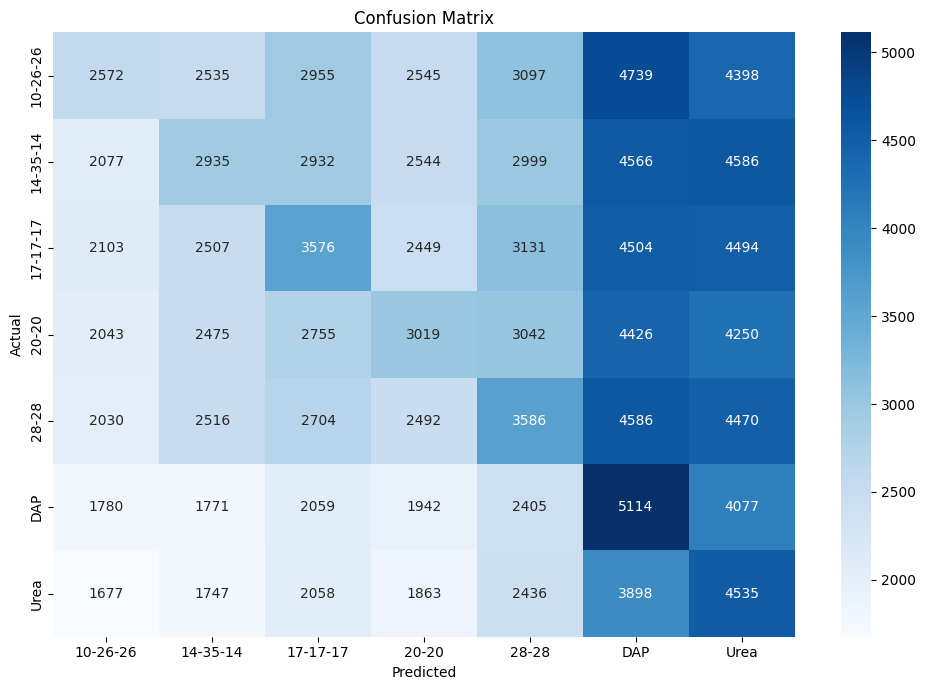

In [60]:
cm = confusion_matrix(y_val_raw, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_model.classes_, 
            yticklabels=final_model.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

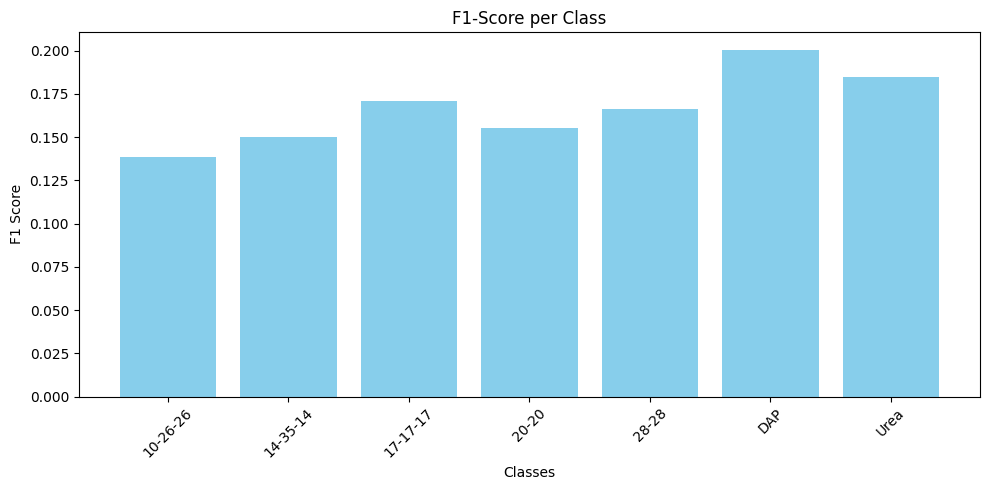

In [61]:
f1_per_class = f1_score(y_val_raw, y_pred, average=None)

plt.figure(figsize=(10, 5))
plt.bar(final_model.classes_, f1_per_class, color='skyblue')

plt.title('F1-Score per Class')
plt.xlabel('Classes')
plt.ylabel('F1 Score')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
full_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [59]:
final_model.fit(x_train, y_train, sample_weight=full_sample_weights)

GradientBoostingClassifier(n_estimators=50, random_state=42)

In [ ]:
test_probabilities = final_model.predict_proba(x_test)
classes = final_model.classes_

In [37]:
top_3_indices = np.argsort(test_probabilities, axis=1)[:, -3:][:, ::-1]

In [38]:
top_3_predictions = [" ".join([classes[idx] for idx in row]) for row in top_3_indices]

In [39]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'Fertilizer Name': top_3_predictions
})

submission_df.to_csv('submission.csv', index=False)

In [40]:
with open('Fertilizer.pkl', 'wb') as f:
    pickle.dump(final_model, f)

In [41]:
model_file_name = "Fertilizer.h5"

with open(model_file_name, 'wb') as f:
    pickle.dump(final_model, f)